<a href="https://colab.research.google.com/github/AishaniiiRoy/Bollywood-EDA/blob/main/Bollywood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving bollywood.csv to bollywood.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('bollywood.csv')

In [ ]:
list(df.columns)

['SlNo',
 'Release Date',
 'MovieName',
 'ReleaseTime',
 'Genre',
 'Budget',
 'BoxOfficeCollection',
 'YoutubeViews',
 'YoutubeLikes',
 'YoutubeDislikes']

In [ ]:
plt.style.use('ggplot')
df.shape

(149, 10)

In [ ]:
df.head(5)


,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224


In [ ]:
df.columns


Index(['SlNo', 'Release Date', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    object 
 2   MovieName            149 non-null    object 
 3   ReleaseTime          149 non-null    object 
 4   Genre                149 non-null    object 
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      149 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 11.8+ KB


In [ ]:
count= df.Genre.value_counts()
print(count)


Genre
Comedy       36
 Drama       35
Thriller     26
Romance      25
Action       21
Thriller      3
Action        3
Name: count, dtype: int64


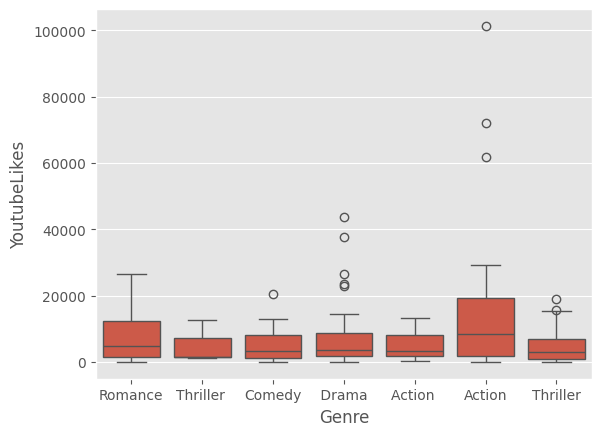

In [ ]:
sns.boxplot(x='Genre',y='YoutubeLikes',data=df);

In [ ]:
df['Genre'].value_counts().idxmax()

'Comedy'

In [ ]:
df[['Genre','MovieName']].sort_values ('Genre',ascending=False)


,Genre,MovieName
20,Thriller,David
1,Thriller,Table No. 21
16,Thriller,Race 2
30,Thriller,Heartless
44,Thriller,3G
...,...,...
120,Drama,Total Siyappa
49,Drama,Kya Dilli Kya Lahore
102,Drama,Kaanchi
40,Drama,"Saheb, Biwi Aur Gangster Returns"


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('Genre').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
pd.crosstab(df['Genre'],df['ReleaseTime'])


ReleaseTime,FS,HS,LW,N
Genre,,,,
Drama,4,6,1,24
Action,3,3,3,12
Action,0,0,0,3
Comedy,3,5,5,23
Romance,3,3,4,15
Thriller,4,1,1,20
Thriller,0,0,1,2


In [ ]:
pd.crosstab(df['Genre'],df['ReleaseTime']).value_counts()

FS  HS  LW  N 
0   0   0   3     1
        1   2     1
3   3   3   12    1
        4   15    1
    5   5   23    1
4   1   1   20    1
    6   1   24    1
Name: count, dtype: int64

In [ ]:
df.groupby(['Genre', 'ReleaseTime']).size()


Genre      ReleaseTime
 Drama     FS              4
           HS              6
           LW              1
           N              24
Action     FS              3
           HS              3
           LW              3
           N              12
Action     N               3
Comedy     FS              3
           HS              5
           LW              5
           N              23
Romance    FS              3
           HS              3
           LW              4
           N              15
Thriller   FS              4
           HS              1
           LW              1
           N              20
Thriller   LW              1
           N               2
dtype: int64

In [ ]:
filtered=df[(df['ReleaseTime']=='LW')&(df['ReleaseTime']=='FS') ]

In [ ]:
genre_counts = filtered['Genre'].value_counts()
print(genre_counts)


Series([], Name: count, dtype: int64)


In [ ]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df['Month'] = df['Release Date'].dt.month_name()
df['Month'].value_counts().idxmax()

<ipython-input-37-2029241458>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release Date'] = pd.to_datetime(df['Release Date'])


'January'

In [ ]:
df['Month'].value_counts()



,count
Month,
January,20
March,19
May,18
July,16
February,16
April,11
June,10
September,10
November,10


In [ ]:
high_budget = df[df['Budget'] > 25]
high_budget['Month'].value_counts().idxmax()


'February'

In [ ]:
df['roi']=(df['BoxOfficeCollection']-df['Budget'])/(df['Budget'])
df.roi


,roi
0,1.888889
1,0.200000
2,-0.600000
3,-0.950000
4,-0.400000
...,...
144,1.000000
145,1.469231
146,-0.625000
147,1.378000


In [ ]:
top10_roi = df[['MovieName', 'roi']].sort_values(by='roi', ascending=False).head(10)
top10_roi.reset_index(drop=True, inplace=True)
top10_roi



,MovieName,roi
0,Aashiqui 2,8.166667
1,PK,7.647059
2,Grand Masti,7.514286
3,The Lunchbox,7.500000
4,Fukrey,6.240000
5,Mary Kom,5.933333
6,Shahid,5.666667
7,Humpty Sharma Ki Dulhania,5.500000
8,Bhaag Milkha Bhaag,4.466667
9,Chennai Express,4.266667


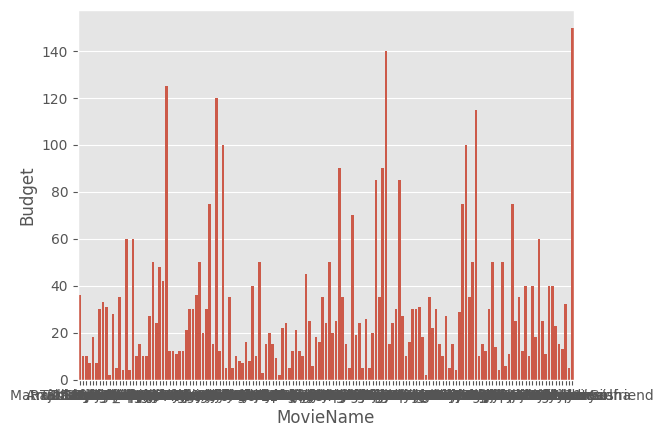

In [ ]:
sns.barplot(x='MovieName',y='Budget',data=df);

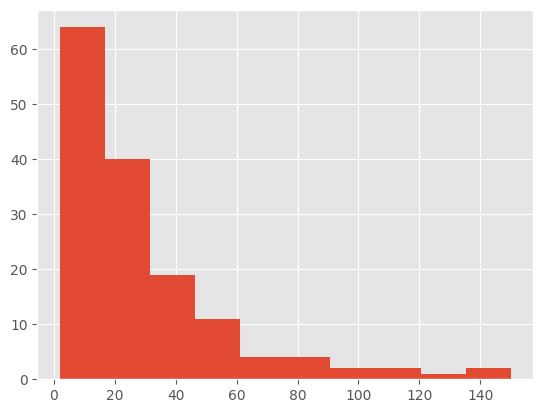

In [ ]:
plt.hist(df['Budget']);

<ipython-input-53-709802373>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Budget'])


<Axes: xlabel='Budget', ylabel='Density'>

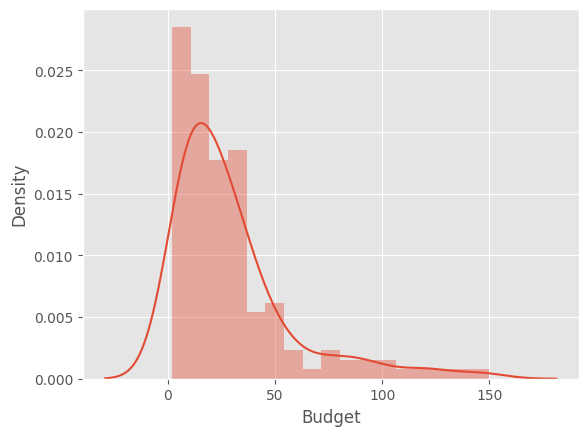

In [ ]:
sns.distplot(df['Budget'])

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


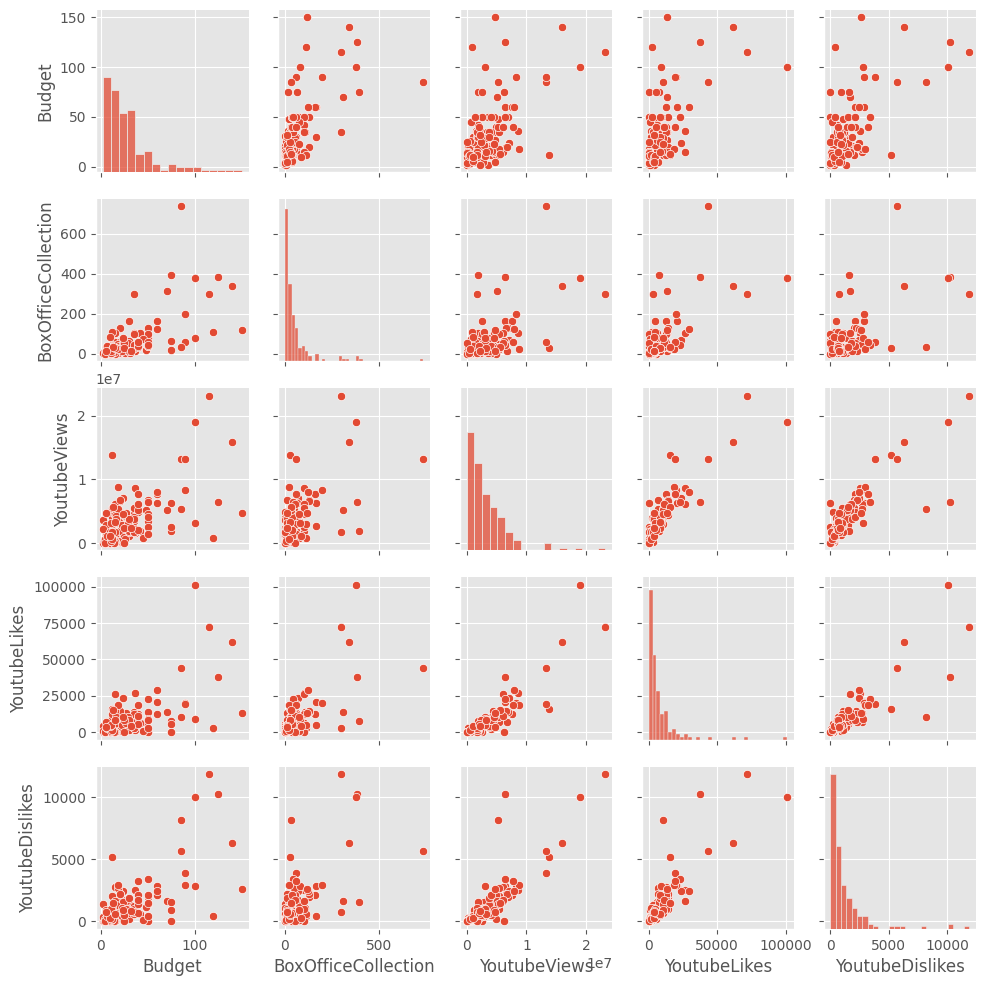

In [ ]:
infuential_features=['Budget','BoxOfficeCollection','YoutubeViews','YoutubeLikes','YoutubeDislikes']
infuential_features
sns.pairplot(df[infuential_features],size=2)